In [6]:
import pandas as pd
# Import all libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, 
                             confusion_matrix,
                             roc_auc_score,
                             roc_curve)
file_path = r"C:\Users\USER\Desktop\PYTHON DASH\diabetes.csv"
df = pd.read_csv(file_path)

# First look at the data
print("=== FIRST 5 ROWS ===")
print(df.head())

print("\n=== SHAPE OF DATA ===")
print("Rows: {}, Columns: {}".format(df.shape[0], df.shape[1]))

print("\n=== COLUMN NAMES ===")
print(df.columns.tolist())

print("\n=== MISSING VALUES ===")
print(df.isna().sum())

print("\n=== BASIC STATISTICS ===")
print(df.describe())

=== FIRST 5 ROWS ===
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

=== SHAPE OF DATA ===
Rows: 768, Columns: 9

=== COLUMN NAMES ===
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

=== MISSING VALUES ===
Pregnancies                 0
Glucose                     0
BloodP

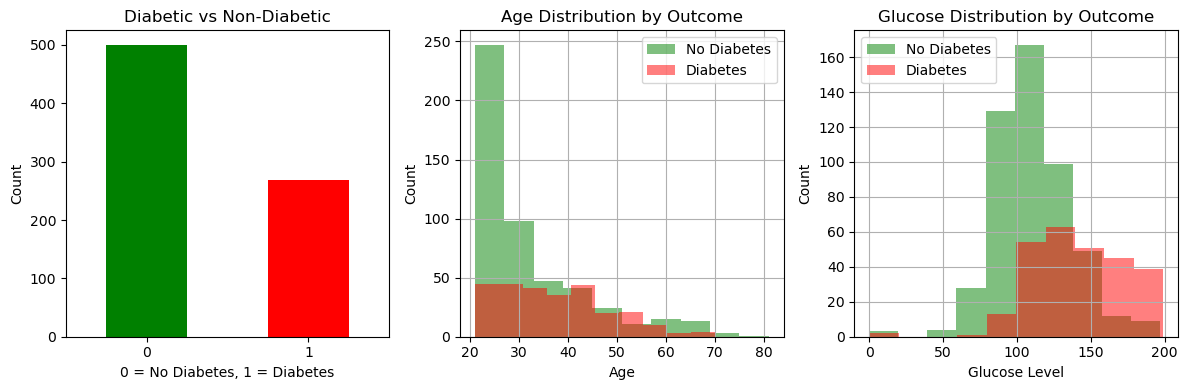

In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Then reload your data
file_path = r"C:\Users\USER\Desktop\PYTHON DASH\diabetes.csv"
df = pd.read_csv(file_path)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
df["Outcome"].value_counts().plot(kind="bar", color=["green", "red"])
plt.title("Diabetic vs Non-Diabetic")
plt.xlabel("0 = No Diabetes, 1 = Diabetes")
plt.ylabel("Count")
plt.xticks(rotation=0)

# Plot 2 - Age distribution
plt.subplot(1, 3, 2)
df[df["Outcome"]==0]["Age"].hist(alpha=0.5, label="No Diabetes", color="green")
df[df["Outcome"]==1]["Age"].hist(alpha=0.5, label="Diabetes", color="red")
plt.title("Age Distribution by Outcome")
plt.xlabel("Age")
plt.ylabel("Count")
plt.legend()

# Plot 3 - Glucose distribution
plt.subplot(1, 3, 3)
df[df["Outcome"]==0]["Glucose"].hist(alpha=0.5, label="No Diabetes", color="green")
df[df["Outcome"]==1]["Glucose"].hist(alpha=0.5, label="Diabetes", color="red")
plt.title("Glucose Distribution by Outcome")
plt.xlabel("Glucose Level")
plt.ylabel("Count")
plt.legend()

plt.tight_layout()
plt.show()

In [7]:
# Create X and y
X = df.drop("Outcome", axis=1).values
y = df["Outcome"].values

print("Features shape: {}".format(X.shape))
print("Target shape: {}".format(y.shape))
print("Diabetes rate: {:.1f}%".format(y.mean() * 100))

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # preserve diabetes ratio in both sets!
)

print("\nTraining set size: {}".format(X_train.shape[0]))
print("Test set size: {}".format(X_test.shape[0]))

Features shape: (768, 8)
Target shape: (768,)
Diabetes rate: 34.9%

Training set size: 614
Test set size: 154


=== MODEL COMPARISON ===

Logistic Regression: Mean=0.785, Std=0.040
KNN: Mean=0.734, Std=0.039
Decision Tree: Mean=0.674, Std=0.044
Random Forest: Mean=0.756, Std=0.030


C:\Users\USER\AppData\Local\Temp\ipykernel_22088\3488054238.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(results, labels=names)


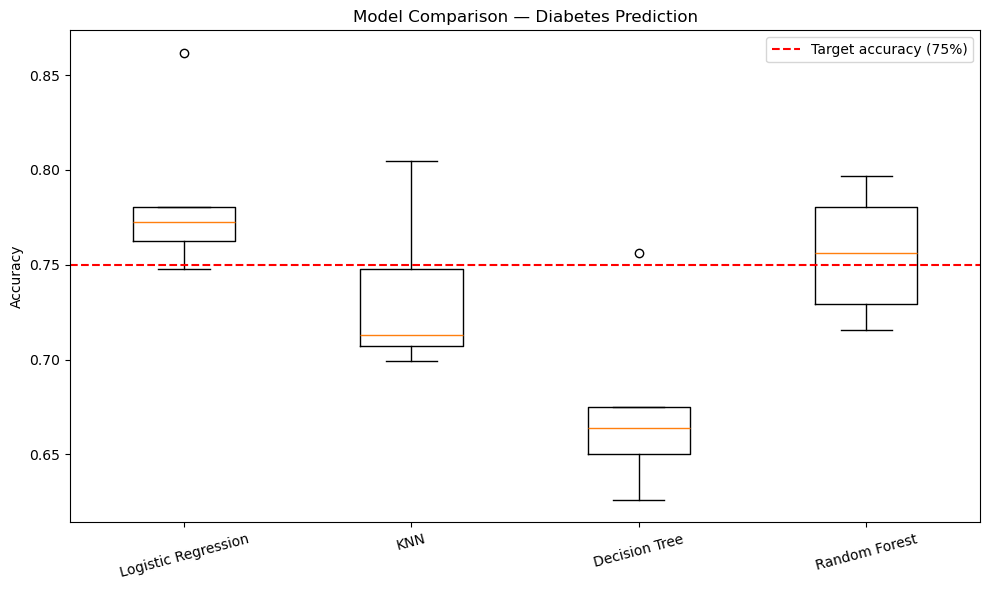

In [8]:
# Define all models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# Compare models using cross validation
results = []
names = []

print("=== MODEL COMPARISON ===\n")
for name, model in models.items():
    
    # Build pipeline with imputer and scaler
    pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="mean")),
        ("scaler", StandardScaler()),
        ("model", model)
    ])
    
    kf = KFold(n_splits=5, random_state=42, shuffle=True)
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=kf)
    results.append(cv_scores)
    names.append(name)
    
    print("{}: Mean={:.3f}, Std={:.3f}".format(
        name, cv_scores.mean(), cv_scores.std()
    ))

# Box plot comparison
plt.figure(figsize=(10, 6))
plt.boxplot(results, labels=names)
plt.title("Model Comparison — Diabetes Prediction")
plt.ylabel("Accuracy")
plt.xticks(rotation=15)
plt.axhline(y=0.75, color="red", linestyle="--", label="Target accuracy (75%)")
plt.legend()
plt.tight_layout()
plt.show()

=== MODEL PERFORMANCE ===

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.79      0.85      0.82       100
    Diabetes       0.68      0.59      0.63        54

    accuracy                           0.76       154
   macro avg       0.74      0.72      0.73       154
weighted avg       0.75      0.76      0.76       154

ROC AUC Score: 0.815


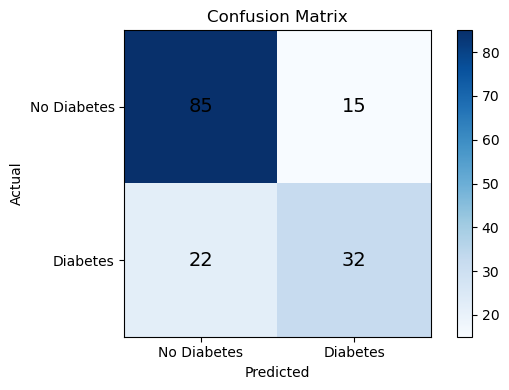

In [9]:
# Train the best model 
best_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("model", RandomForestClassifier(random_state=42))
])

# Fit on training data
best_pipeline.fit(X_train, y_train)

# Make predictions
y_pred = best_pipeline.predict(X_test)
y_pred_probs = best_pipeline.predict_proba(X_test)[:, 1]

# Print results
print("=== MODEL PERFORMANCE ===\n")
print("Classification Report:")
print(classification_report(y_test, y_pred,
      target_names=["No Diabetes", "Diabetes"]))

print("ROC AUC Score: {:.3f}".format(roc_auc_score(y_test, y_pred_probs)))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ["No Diabetes", "Diabetes"])
plt.yticks([0, 1], ["No Diabetes", "Diabetes"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", 
                fontsize=14, color="black")
plt.tight_layout()
plt.show()

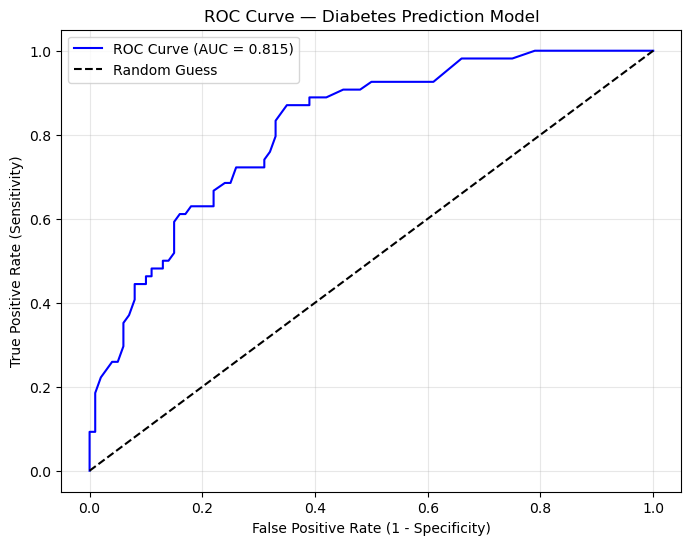

In [10]:
# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
auc_score = roc_auc_score(y_test, y_pred_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="blue", 
         label="ROC Curve (AUC = {:.3f})".format(auc_score))
plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curve — Diabetes Prediction Model")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

=== AI SAFETY BIAS ANALYSIS ===

Accuracy for patients under 30:  80.0%
Accuracy for patients 30-50:     70.4%
Accuracy for patients over 50:   73.3%


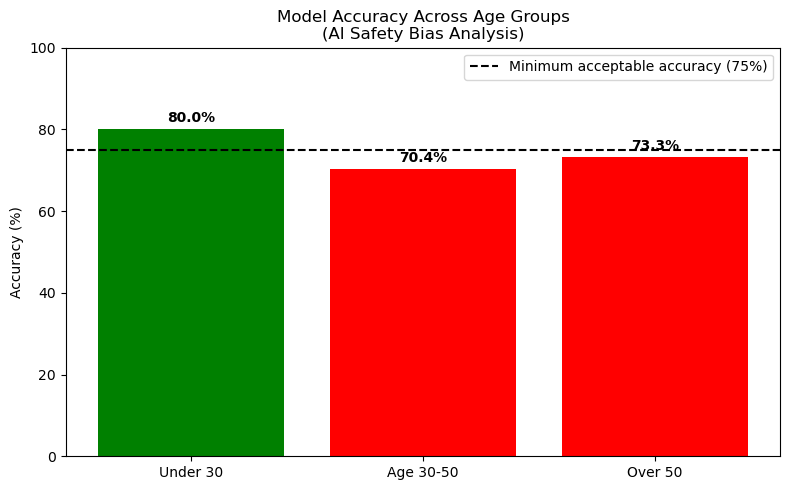


=== KEY INSIGHT ===
If any group scores below 75%, the model is BIASED!
Biased medical AI = dangerous for underrepresented patients!
This is exactly why AI Safety matters in healthcare! 🏥


In [11]:

feature_names = df.drop("Outcome", axis=1).columns.tolist()
age_idx = feature_names.index("Age")

# Get test set as DataFrame for easy filtering
X_test_df = pd.DataFrame(X_test, columns=feature_names)
X_test_df["Actual"] = y_test
X_test_df["Predicted"] = y_pred

# Split into age groups
young   = X_test_df[X_test_df["Age"] < 30]
middle  = X_test_df[(X_test_df["Age"] >= 30) & (X_test_df["Age"] < 50)]
older   = X_test_df[X_test_df["Age"] >= 50]

def get_accuracy(group):
    if len(group) == 0:
        return 0
    return (group["Actual"] == group["Predicted"]).mean()

young_acc  = get_accuracy(young)
middle_acc = get_accuracy(middle)
older_acc  = get_accuracy(older)

print("=== AI SAFETY BIAS ANALYSIS ===\n")
print("Accuracy for patients under 30:  {:.1f}%".format(young_acc * 100))
print("Accuracy for patients 30-50:     {:.1f}%".format(middle_acc * 100))
print("Accuracy for patients over 50:   {:.1f}%".format(older_acc * 100))

# Visualize bias
groups = ["Under 30", "Age 30-50", "Over 50"]
accuracies = [young_acc, middle_acc, older_acc]
colors = ["green" if a >= 0.75 else "red" for a in accuracies]

plt.figure(figsize=(8, 5))
bars = plt.bar(groups, [a * 100 for a in accuracies], color=colors)
plt.axhline(y=75, color="black", linestyle="--", 
            label="Minimum acceptable accuracy (75%)")
plt.title("Model Accuracy Across Age Groups\n(AI Safety Bias Analysis)")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.legend()

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 1,
             "{:.1f}%".format(acc * 100), 
             ha="center", va="bottom", fontweight="bold")
plt.tight_layout()
plt.show()

print("\n=== KEY INSIGHT ===")
print("If any group scores below 75%, the model is BIASED!")
print("Biased medical AI = dangerous for underrepresented patients!")
print("This is exactly why AI Safety matters in healthcare! 🏥")

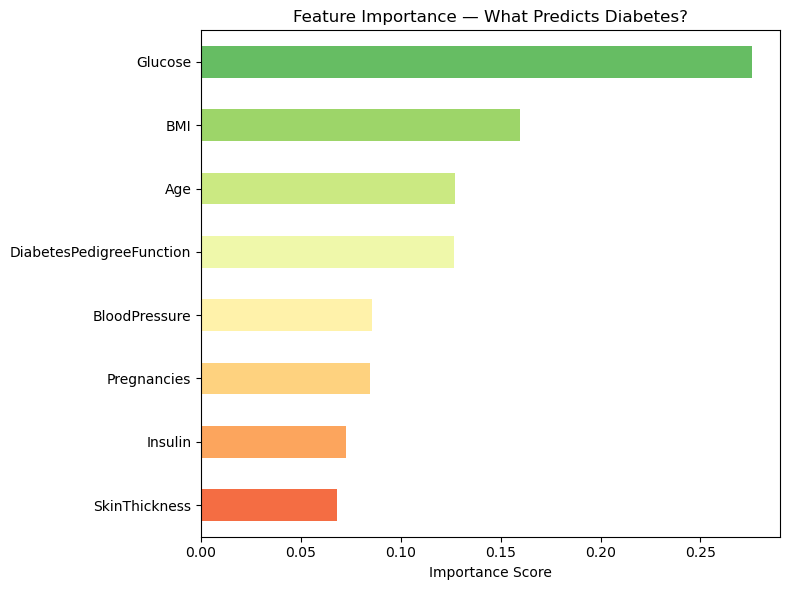


Top 3 most important features:
1. Glucose (27.6%)
2. BMI (16.0%)
3. Age (12.7%)


In [12]:
# Which symptoms matter most?
rf_model = best_pipeline.named_steps["model"]
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=feature_names
).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
colors = plt.cm.RdYlGn(
    np.linspace(0.2, 0.8, len(feature_importance))
)
feature_importance.plot(kind="barh", color=colors)
plt.title("Feature Importance — What Predicts Diabetes?")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("\nTop 3 most important features:")
for i, (feat, imp) in enumerate(
    feature_importance.sort_values(ascending=False).head(3).items()
):
    print("{}. {} ({:.1f}%)".format(i+1, feat, imp*100))